I need to come up with parameters of what a good reconstruction

- The reconstruction is faithful to input.  
  - first lets do this, we want a dictionary learning which gives faithful representations
  - For now, i look at the representations
  - The loss is quite opaque in this i feel from dict learning
  - Lets try on sparse components
  - Although dict learning is very resistent to noise, i don't know how to compare good fits because the loss is always so small
- I'm able to tag the input with the reconstructed data.  
  - for now, we simply wanna tag the patches which were "caught" correctly
  - This is dependent on the fact that we get faithful reconstruction :)
- Generally, measuring faithfulness itself is slightly difficult lol

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import django

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [3]:
from neural_data.models import *
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pt_to_api.utils import show_single_channel_red_green_black as S, to_show_list as tsl, show_72, show_72_list, scatter_plot_1d, mk_rect_on_ax, get_receptive
from tqdm import tqdm
from pt_to_api.contribs.v1 import show_input_patch_and_kernel_placement_for_poi_using_raw_params as SIP
import seaborn as sns
import numpy as np
from sklearn.decomposition import MiniBatchDictionaryLearning, DictionaryLearning
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import pairwise_distances, cosine_similarity, cosine_distances
from scipy.optimize import linear_sum_assignment
import pandas as pd
from collections import defaultdict

from neural_data.utils import get_full_conv_kernel_at_coordinate, get_saliency_map_ids_and_patches, get_full_activations_of_layer
import itertools

In [4]:
KERNEL_COORDINATE = "layers.2.out_12"
INPUT_LAYER_NAME = "layers.1"
R = 2
C = 3
MODE = "light"

100%|██████████| 5502/5502 [00:00<00:00, 1512753.89it/s]


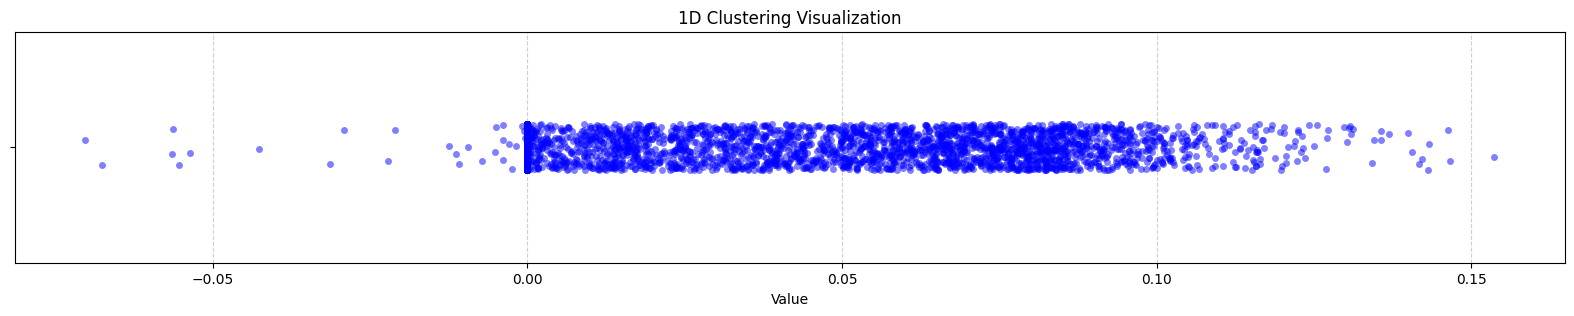

In [ ]:
kernel = get_full_conv_kernel_at_coordinate(KERNEL_COORDINATE)
vals = []
for sm in tqdm(SaliencyMap.objects.filter(coordinate=KERNEL_COORDINATE)):
    vals.append(sm.data[R][C])

scatter_plot_1d(vals)

In [ ]:
from typing import Literal

def _single_dict_learn(X, n_components, alg: Literal["minibatch", "basic"], seed=None, **kwargs):
    clz = DictionaryLearning if alg == "basic" else MiniBatchDictionaryLearning
    dl = clz(
        n_components=n_components, random_state=seed, **kwargs
    )
    dl.fit(X)
    codes = dl.transform(X)
    error = np.mean((X - codes @ dl.components_) ** 2)
    return dl, codes, error


def do_dict_learn(inputs, n_components, alg: Literal["minibatch", "basic"] = "basic", n_init=5, **kwargs):
    # X = Normalizer("max").fit_transform(inputs)
    X = inputs.copy()
    kwargs = {
        "alpha": 1,
        "max_iter": 5000,
        **kwargs,
    }
    if n_init == 1:
        dl, codes, error = _single_dict_learn(X, n_components, alg, None, **kwargs)
        return (dl, codes, X), [dl]


    best_dl, best_codes, best_error = None, None, np.inf
    all_dls = []
    for seed in range(n_init):
        dl, codes, error = _single_dict_learn(X, n_components, alg, seed, **kwargs)
        all_dls.append(dl)
        if error < best_error:
            best_dl, best_codes, best_error = dl, codes, error
    return (best_dl, best_codes, X), all_dls


In [ ]:
def get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes, alpha_for_code_below=0.05):
    idxes = []
    for i in range(len(sparse_codes)):
        non_zero_codes = sparse_codes[i][sparse_codes[i] != 0]
        if len(non_zero_codes) == 0:
            continue
        non_zero_codes = np.abs(non_zero_codes)
        max_val_idx = np.argmax(non_zero_codes)
        thresh = non_zero_codes[max_val_idx] * alpha_for_code_below

        gt_thresh = []
        for j in range(len(non_zero_codes)):
            if j == max_val_idx:
                continue
            if non_zero_codes[j] > thresh:
                gt_thresh.append(non_zero_codes[j])
        if len(gt_thresh) > 0:
            idxes.append(i)

    return len(idxes) / sparse_codes.shape[0]

def plot_error_metrics(l2_dicts):
    df = pd.DataFrame.from_dict(l2_dicts, orient="index")
    metrics = ["max", "mean", "50", "75", "90", "95"]
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))

    for ax, metric in zip(axes.flatten(), metrics):
        ax.plot(df.index, df[metric])
        ax.set_title(metric)
    plt.show()


def get_metrics(dl, sparse_codes, X):
    reconstructed = sparse_codes @ dl.components_
    diff = (X - reconstructed)
    err_sq = np.linalg.norm(diff, axis=1)

    _p = np.percentile
    metrics = {
        "l2": {
            "max": np.max(err_sq),
            "mean": np.mean(err_sq),
            "50": _p(err_sq, 50),
            "75": _p(err_sq, 75),
            "90": _p(err_sq, 90),
            "95": _p(err_sq, 95),
        },
        "err": err_sq,
    }
    return metrics

def show_dl_comps(comps):
    c = list(itertools.chain.from_iterable([tsl(c.reshape(8,3,3)) for c in comps]))
    S(c, (20,15), 8, mode=MODE)
    plt.show()


def get_sparsity_in_rows(sparse_codes):
    # < 0.2 is good, < 0.1 is quite nice
    each_row_sparsity = ((sparse_codes != 0).sum(axis=1) / sparse_codes.shape[1])
    _p = np.percentile
    return {
        "max": np.max(each_row_sparsity),
        "mean": np.mean(each_row_sparsity),
        "50": _p(each_row_sparsity, 50),
        "75": _p(each_row_sparsity, 75),
        "90": _p(each_row_sparsity, 90),
        "95": _p(each_row_sparsity, 95),
    }

In [ ]:
def make_sparse(patch, num_std=1):
    mean, std = np.mean(patch), np.std(patch)
    thresh = mean + num_std * std

    sparse = patch.copy()
    sparse[np.abs(sparse) < thresh] = 0
    return sparse

In [ ]:
sparse_pw = make_sparse(lin_pw)

 78%|███████▊  | 46/59 [02:07<00:36,  2.79s/it]/Users/hariomnarang/Desktop/personal/hiccup-ide/backend/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.826e-07, tolerance: 3.579e-08
  model = cd_fast.enet_coordinate_descent_gram(
/Users/hariomnarang/Desktop/personal/hiccup-ide/backend/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.998e-07, tolerance: 5.459e-08
  model = cd_fast.enet_coordinate_descent_gram(
 80%|███████▉  | 47/59 [02:10<00:33,  2.83s/it]/Users/hariomnarang/Desktop/personal/hiccup-ide/backend/.venv/lib/python3.13/site-packages/sklea

n_components v/s loss


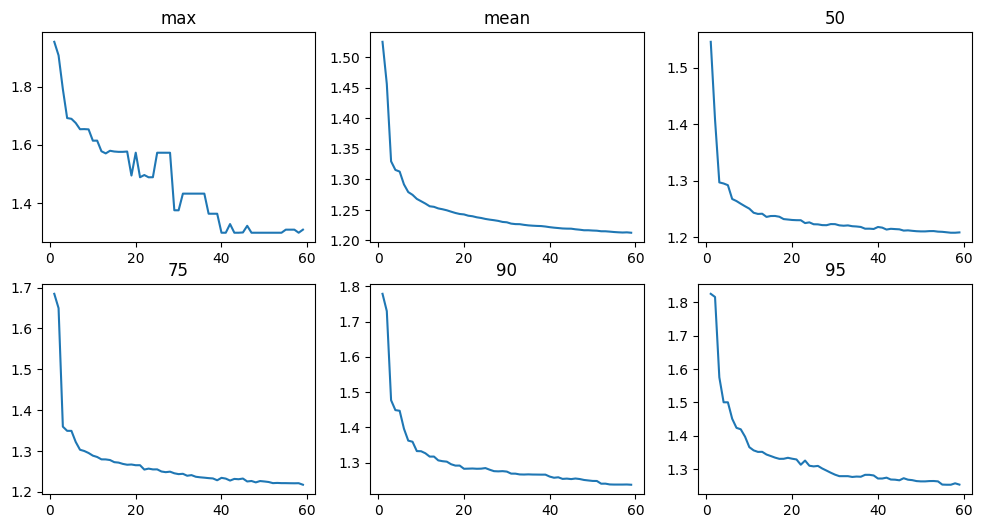

n_components v/s sparsity


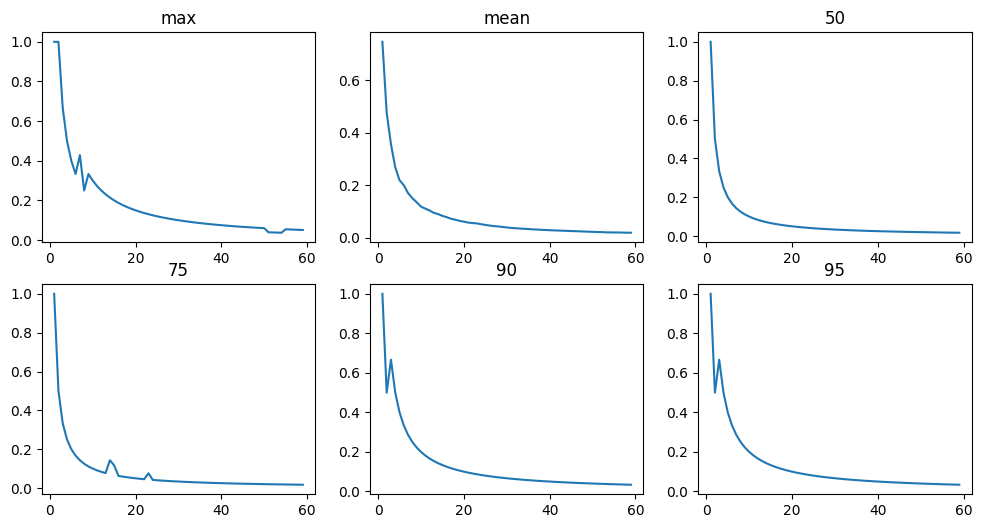

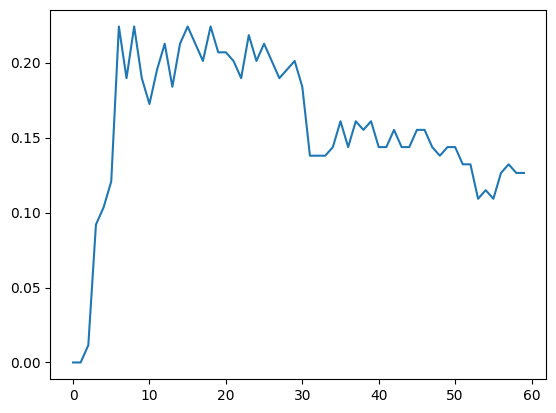

In [15]:
l2_dicts = {}
sparsity_per_row = {}
distance_between_seeds = {}
comps_gt_1_per_row_ratio = [0] # placeholder for 0
for comp in tqdm(range(1,60)):
    (dl, sparse_codes, X), all_dls = do_dict_learn(sparse_pw, comp, "basic", alpha=1.2, max_iter=30000, transform_algorithm="lasso_cd")
    error_metrics = get_metrics(dl, sparse_codes, X)
    sparsity_per_row[comp] = get_sparsity_in_rows(sparse_codes)
    l2_dicts[comp] = error_metrics["l2"]
    comps_gt_1_per_row_ratio.append(get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes))

print("n_components v/s loss")
plot_error_metrics(l2_dicts)

print("n_components v/s sparsity")
plot_error_metrics(sparsity_per_row)


plt.plot(comps_gt_1_per_row_ratio)
plt.show()

In [ ]:
def get_sparse_components(sparse_codes, dl_components, index):
    codes = sparse_codes[index]
    return [codes[i] * dl_components[i] for i in range(len(codes)) if codes[i] != 0]

In [12]:
(dl, sparse_codes, X), all_dls = do_dict_learn(sparse_pw, 30, "basic", alpha=1.2, max_iter=30000, transform_algorithm="lasso_cd")

NameError: name 'do_dict_learn' is not defined

In [13]:
def show_normalized(x, recons):
    norm = Normalizer("max")
    show_72_list([norm.fit_transform(recons.reshape(1,-1)), norm.fit_transform(x.reshape(1,-1))], mode=MODE)
    plt.show()

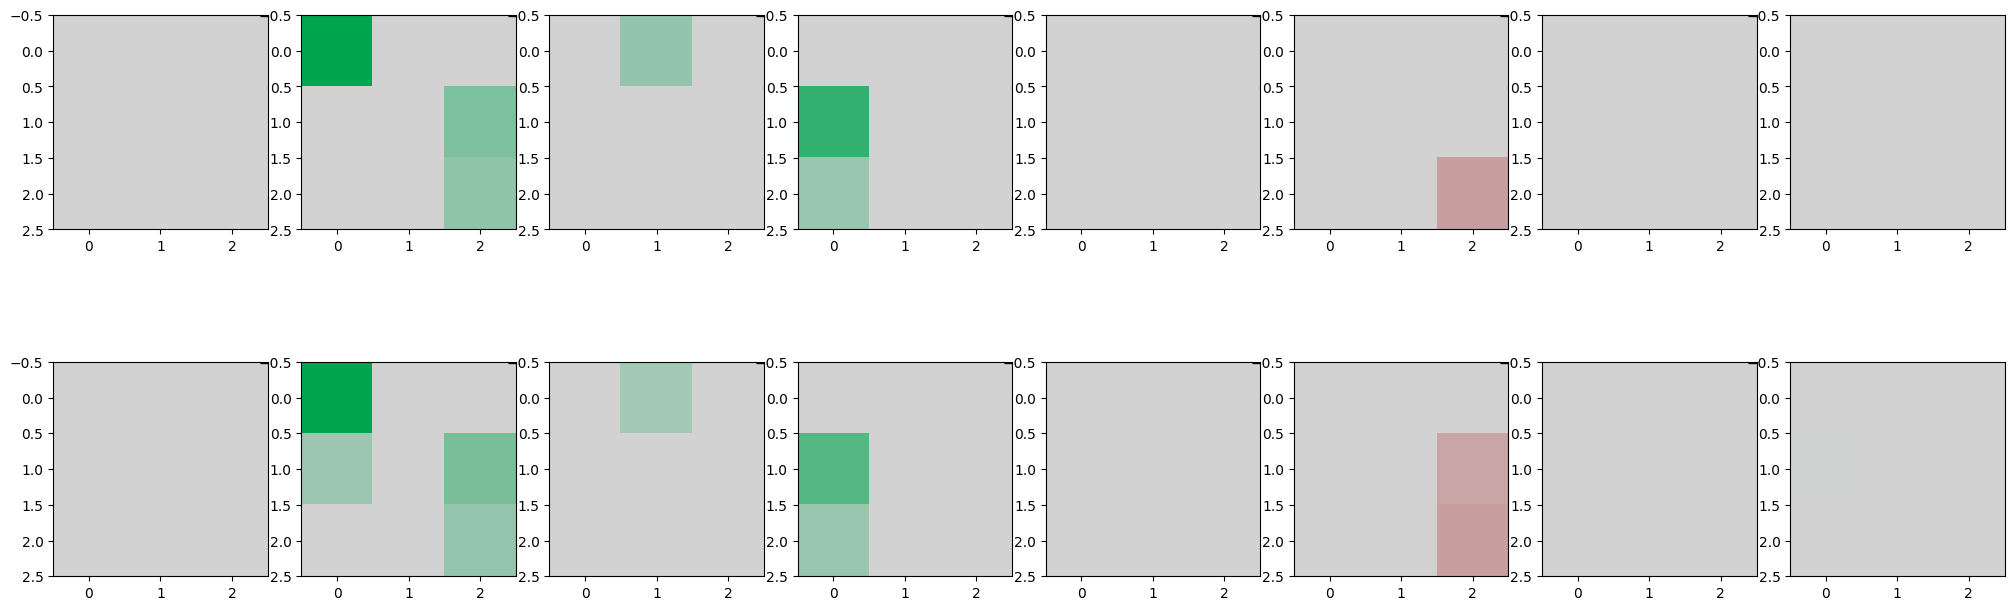

sparse components


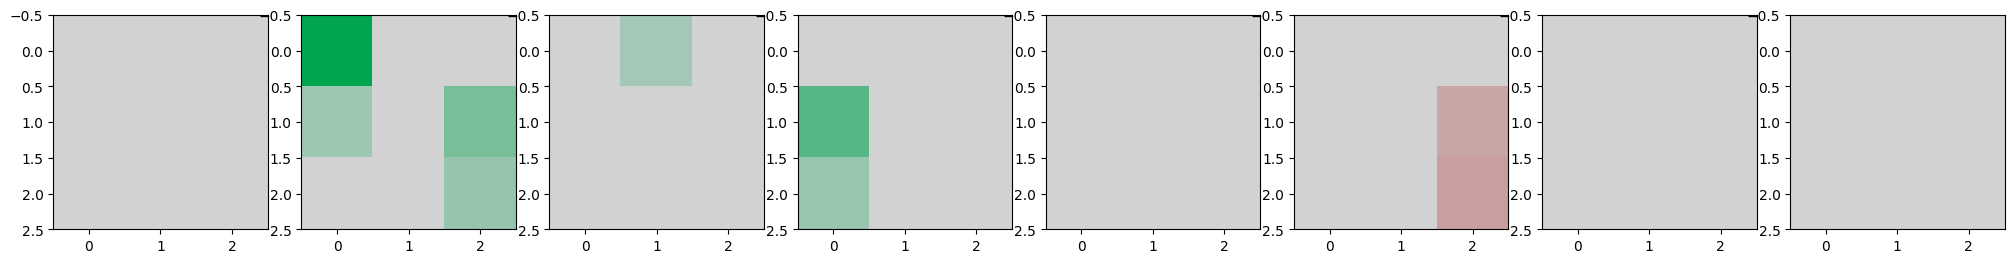

In [15]:
recons = sparse_codes @ dl.components_

# these are definitely not pure components, have a lot of redundancy
# im also not able to get perfect sparsity
# print(sparse_codes)
# show_72_list([norm.fit_transform(recons[0].reshape(1,-1)), norm.fit_transform(X[0].reshape(1,-1))], mode=MODE)
show_normalized(recons[0], X[0])
print("sparse components")
# there was only one component lol
show_72_list(get_sparse_components(sparse_codes, dl.components_, 0), mode=MODE)

In [19]:
def patch_from_recons(recons, kernel):
    # simply pointwise divide by kernel
    k = kernel.reshape(-1)
    recons = recons.reshape(-1)
    # patch = recons / k
    patch = np.where(k == 0, np.nan, recons / k)
    return patch.reshape(8,3,3)

In [26]:
patches[0].shape

(8, 3, 3)

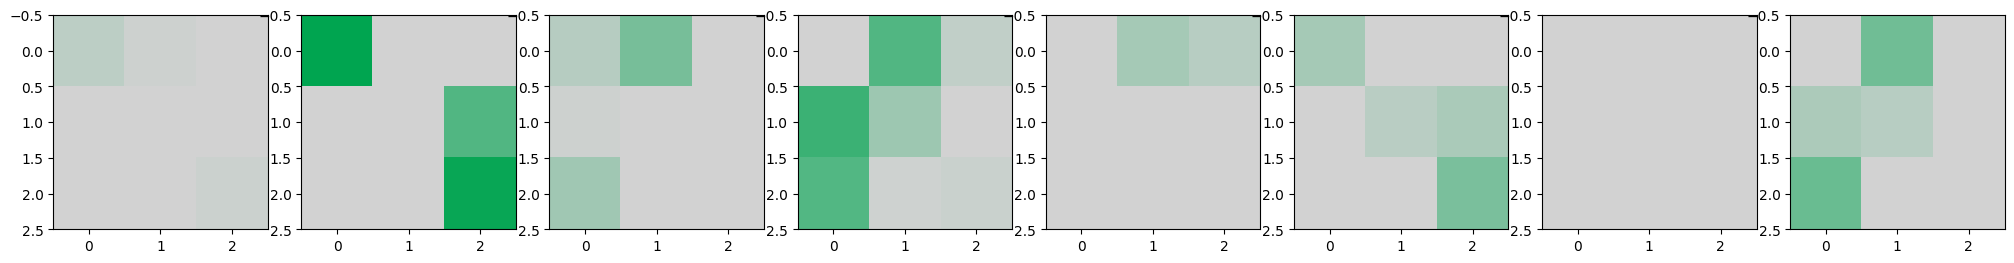

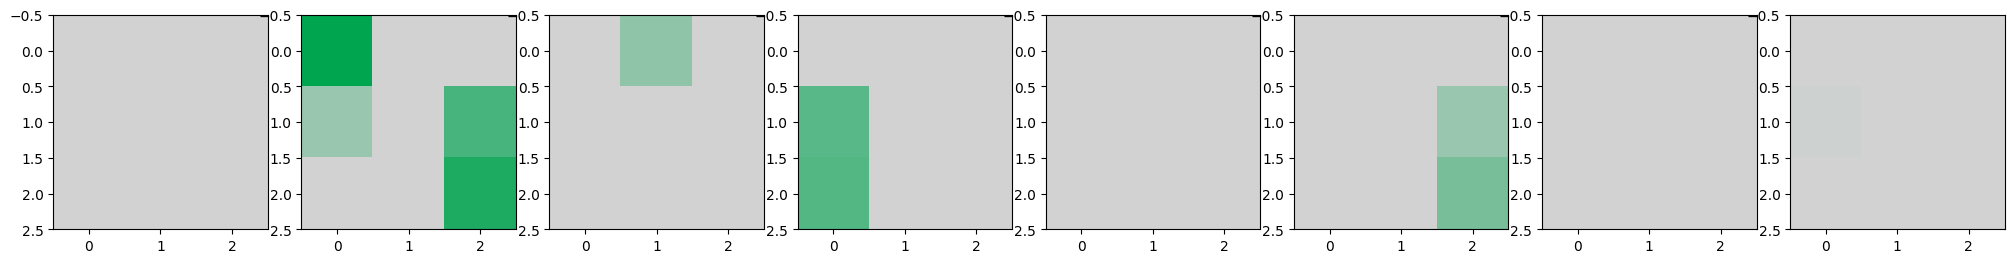

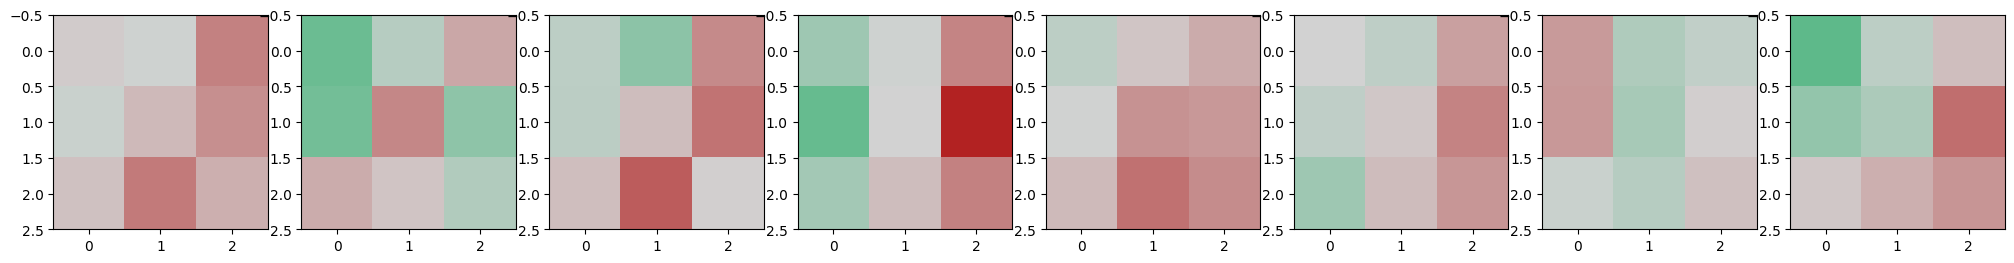

In [29]:
S(tsl(patches[0]),(20,8),8,mode=MODE)
S(tsl(patch_from_recons(recons[0],kernel)),(20,8),8,mode=MODE)
S(tsl(kernel),(20,8),8,mode=MODE)
plt.show()

The main job is somehow being able to interpret these results.  
Since the reconstructed array has very less noise, we want to create a metric on how similar each is to the other.  
we can do this using cosine distances, or euclidean, lets see

In [30]:
distances = cosine_distances(recons)
np.argmin(distances[0][1:])

np.int64(20)

In [31]:
distances[0][21]

np.float64(0.0)

The reconstruction is not very bad though, its now useful to see the similarities between the two by comparing the input images

In [32]:
input_acts_0 = get_full_activations_of_layer("layers.1", Input.objects.get(alias=sm_ids[0]["input"]))
input_acts_21 = get_full_activations_of_layer("layers.1", Input.objects.get(alias=sm_ids[21]["input"]))

In [33]:
def get_rect(y, x, ksize=3, stride=2, padding=1):
    (y0,x0), (y1,x1) = get_receptive(y, x, ksize, stride, padding)
    return (y0, x0, y1-y0, x1-x0)

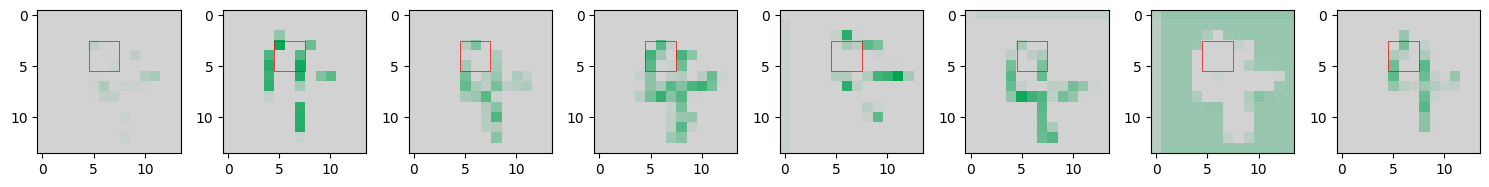

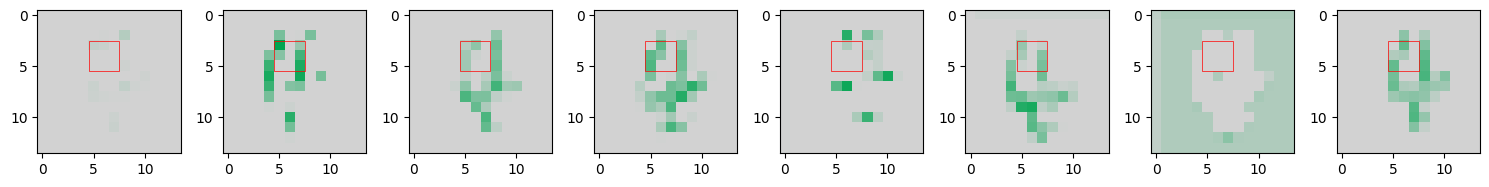

In [ ]:
axes = S(tsl(input_acts_0), (15,5), ncols=8, mode=MODE)
for ax in axes:
    mk_rect_on_ax(ax, *get_rect(R, C))
plt.show()
axes = S(tsl(input_acts_21), (15,5), ncols=8, mode=MODE)
for ax in axes:
    mk_rect_on_ax(ax, *get_rect(R, C))
plt.show()

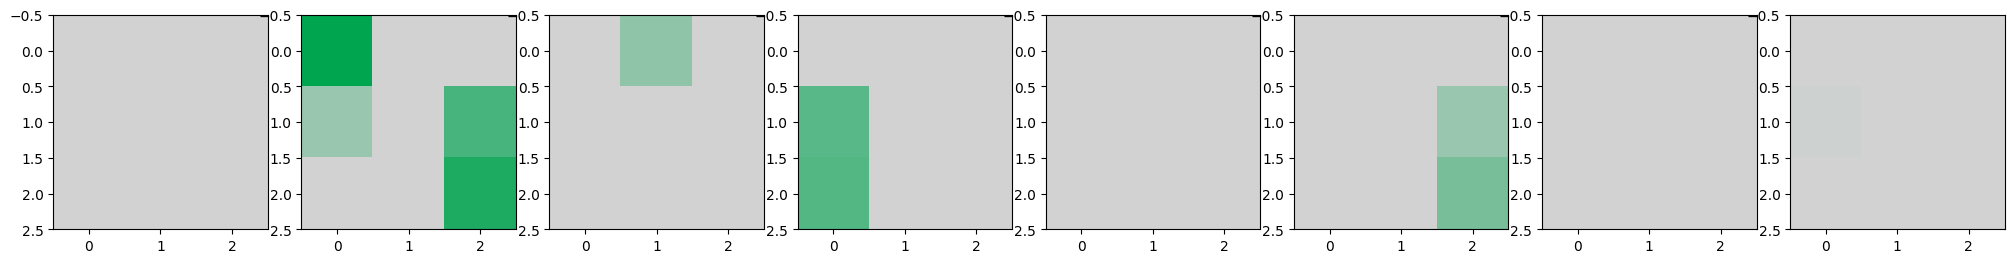

In [37]:
S(tsl(patch_from_recons(recons[0],kernel)),(20,8),8,mode=MODE)
plt.show()

In [79]:
recons[0].shape

(72,)

In [119]:
def patch_from_recons(recons, kernel):
    # simply pointwise divide by kernel
    k = kernel.reshape(-1)
    recons = recons.reshape(-1)
    # patch = recons / k
    patch = np.where(k == 0, np.nan, recons / k)
    return patch.reshape(8,3,3)

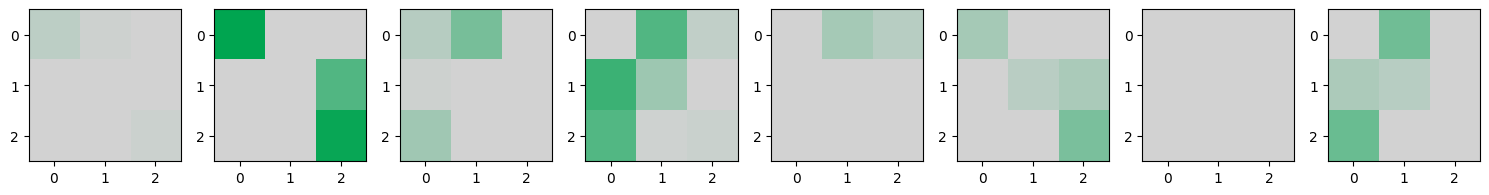

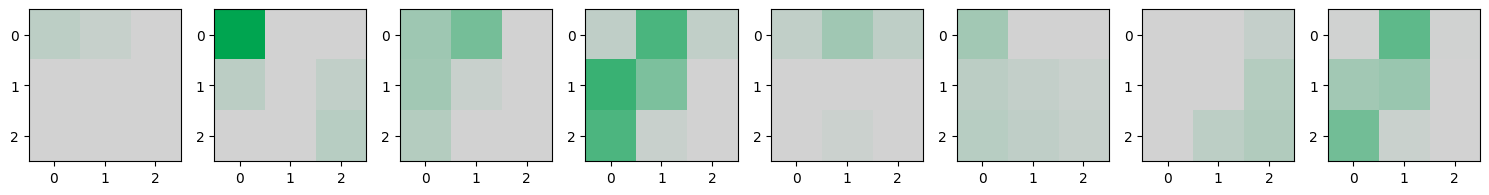

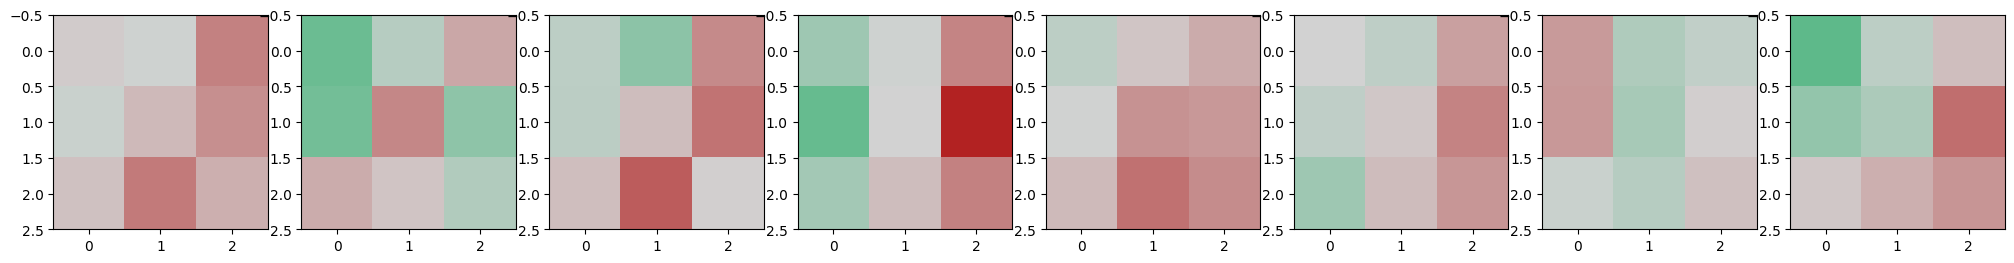

In [96]:
# these are quite similar, although some dims are missed
# the sparse code simply tells us that this is one atom
# note that not having recons be patch is a problem
# we can mitigate it by only showing the patch caught by recons
S(tsl(patches[0])  , (15,5), 8, mode=MODE)
plt.show()
S(tsl(patch_from_recons(recons[0], kernel)), (15,5), 8, mode=MODE)
# S(tsl(patch_from_recons(recons[0], kernel)), (15,5), 8, mode=MODE)
plt.show()
show_72(kernel, mode=MODE)
plt.show()

Reconstruction is bad for smaller components for sure, not sure if that is a good thing or bad for now.  

In [39]:
distances = cosine_distances(dl.components_)

In [41]:
distances.shape,dl.components_.shape

((30, 30), (30, 72))

In [43]:
np.argmin(distances[0][1:])

np.int64(10)

In [45]:
distances[0][10]

np.float64(0.2941700054540951)

# Check what pattern a component is finding

- The first and the most interesting is seeing if patterns are coherent.
  - That is, i can find what meaning came out
  - The easiest is to first find an input where a single component fired alone.  
    - In this case, i would like to see the pattern the component caught
    - basically make rects around all the vector components where the component was non-zero
- We do this across input activations

In [ ]:
# get activation from sm_id


In [79]:
sparse_codes.shape


(174, 30)

In [85]:
def find_pure_patches(codes, k, threshold=1e-3):
    other_cols = np.concatenate([codes[:, :k], codes[:, k+1:]], axis=1)
    mask = (np.abs(codes[:, k]) > threshold) & (np.all(np.abs(other_cols) < threshold, axis=1))
    return np.where(mask)[0]

def find_high_contribution_patches(codes, k, percentile=75):
    contributions = np.abs(codes[:, k])
    threshold = np.percentile(contributions[contributions > 0], percentile)
    return np.where(contributions >= threshold)[0]

def find_patches_for_component(codes, k, pure_threshold=1e-3, high_percentile=75):
    pure = find_pure_patches(codes, k, threshold=pure_threshold)
    high = find_high_contribution_patches(codes, k, percentile=high_percentile)
    
    high_only = high[~np.isin(high, pure)]
    high_only_sorted = high_only[np.argsort(np.abs(codes[high_only, k]))[::-1]]
    
    return np.concatenate([pure, high_only_sorted])

In [166]:
def draw_patches_with_rects_on_coords(input_acts, recons_3d, non_zero_idxs):
    print("input activations")
    axes = S(tsl(input_acts), (20,8), 8, mode=MODE)
    for ax_idx, ax in enumerate(axes):
        for non_zero_i in non_zero_idxs:
            if non_zero_i[0] == ax_idx:
                _, y_rel, x_rel = non_zero_i
                (y0,x0), _ = get_receptive(R, C)
                pw_val = recons_3d[*non_zero_i]
                color = "r" if pw_val < 0 else "black"
                mk_rect_on_ax(ax, y0+y_rel, x0+x_rel, 1, 1, color)
    plt.show()

def summarize_pattern_of_component(comp_num, sm_ids, sparse_codes, dl, kernel):
    idxes = find_patches_for_component(sparse_codes, comp_num)
    if len(idxes) == 0:
        print(f"could not find any contribution of component {comp_num}, its redundant")
        return

    i = idxes[0]
    for j, i in enumerate(idxes[:5]):
        recons_i = (sparse_codes[i] @ dl.components_)
        recons_3d = recons_i.reshape(8,3,3)
        non_zero_idxs = np.argwhere(np.abs(recons_3d) > 0.005)

        input_acts = get_full_activations_of_layer("layers.1", Input.objects.get(alias=sm_ids[i]["input"]))
        patch_i = patch_from_recons(recons_i, kernel)

        if j == 0:
            print("first patch")
            print("reconstructed pointwise")
            show_72(recons_i, mode=MODE)
            plt.show()
            print("reconstructed patch")
            S(tsl(patch_i), (20,8), 8, mode=MODE)
            plt.show()
            print("kernel")
            S(tsl(kernel), (20,8), 8, mode=MODE)
            plt.show()
    
        print("##### input activations ######")
        draw_patches_with_rects_on_coords(input_acts, recons_3d, non_zero_idxs)

    # print("activations for multiple inputs")
    # for j, i in enumerate(idxes[:5]):
    #     recons_i = (sparse_codes[i] @ dl.components_)
    #     # recons_3d = recons_i.reshape(8,3,3)
    #     # nonzero_spatial = np.any(recons_3d != 0, axis=0)  # (3, 3) bool mask
    #     # nonzero_rc = np.argwhere(nonzero_spatial)  # list of (r, c) in patch space
    #     non_zero_idxs = np.argwhere(np.abs(recons_i.reshape(8,3,3)) > 0.005)

first patch
reconstructed pointwise


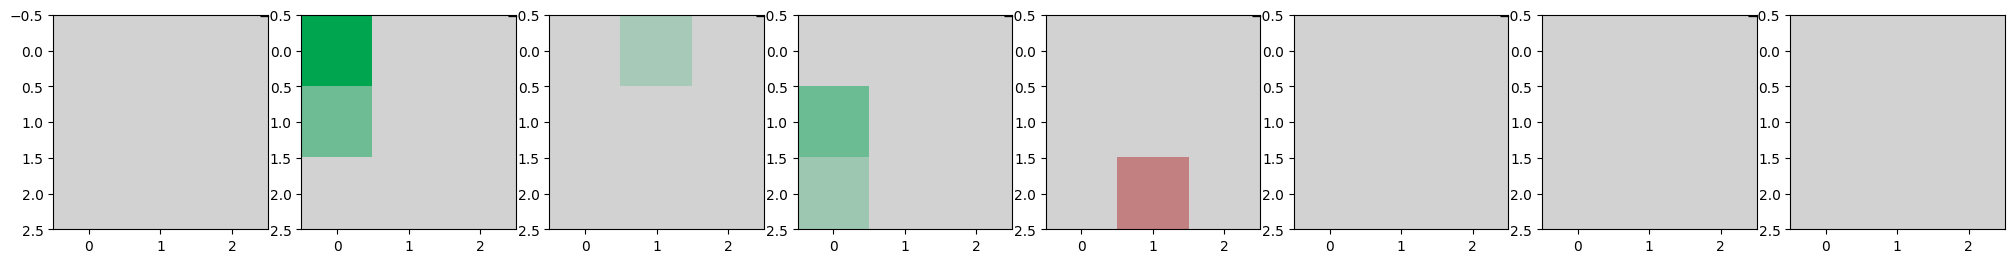

reconstructed patch


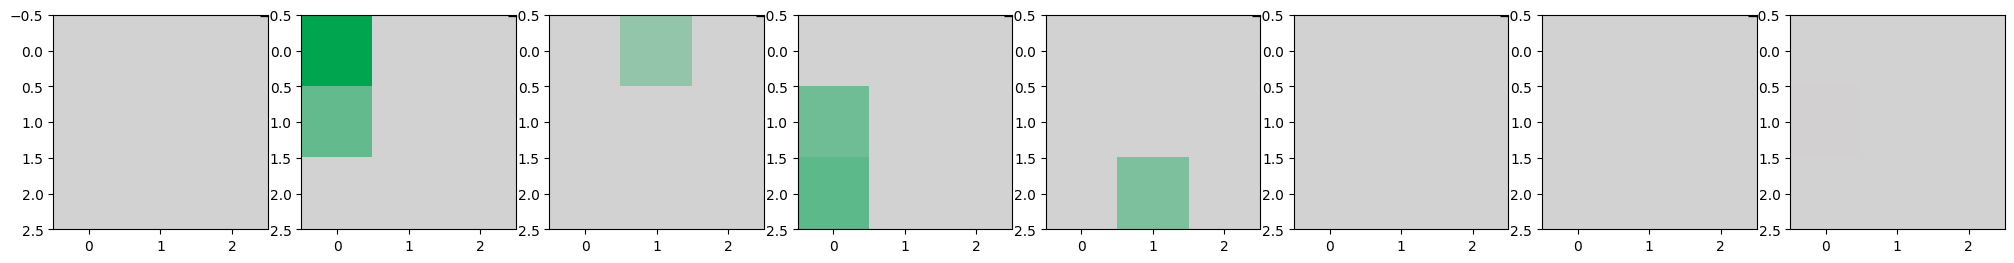

kernel


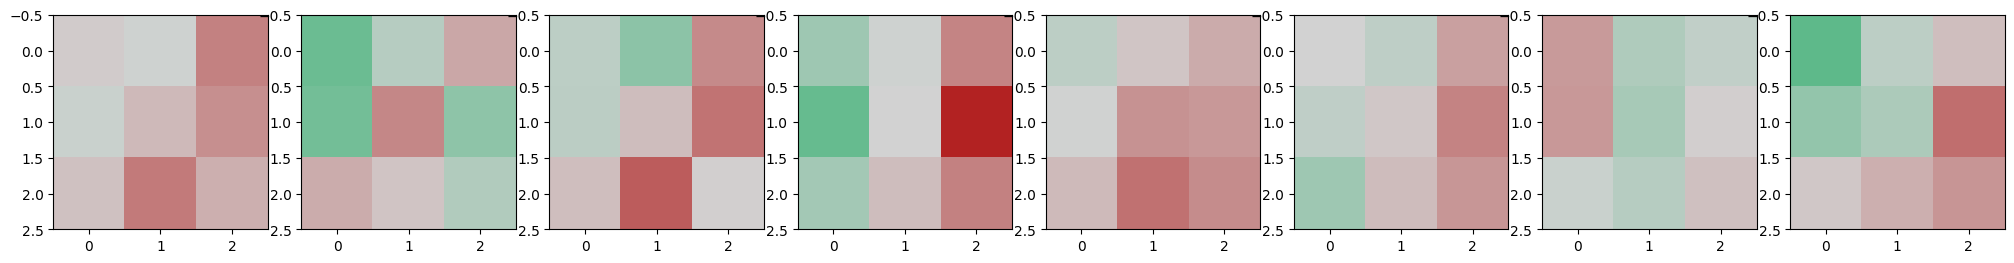

##### input activations ######
input activations


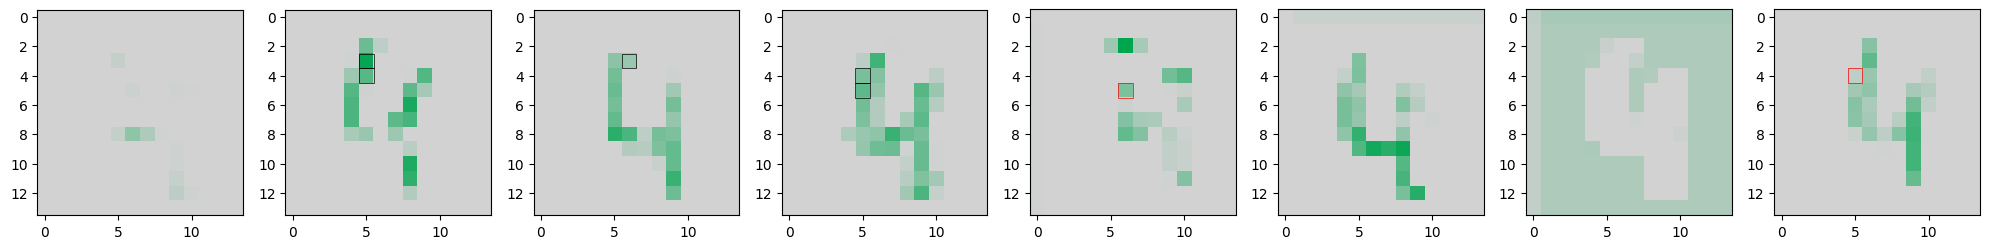

In [167]:
summarize_pattern_of_component(0, sm_ids, sparse_codes, dl, kernel)

first patch
reconstructed pointwise


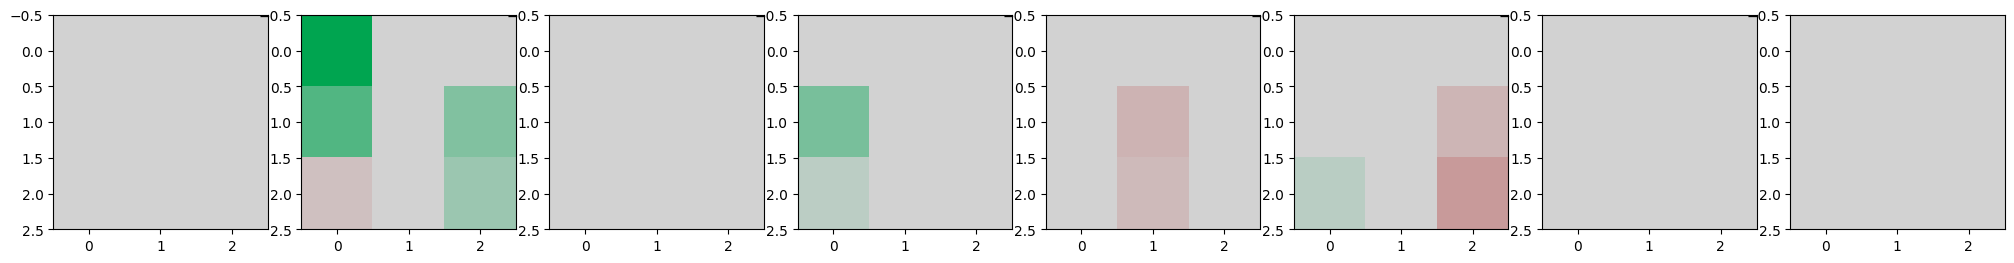

reconstructed patch


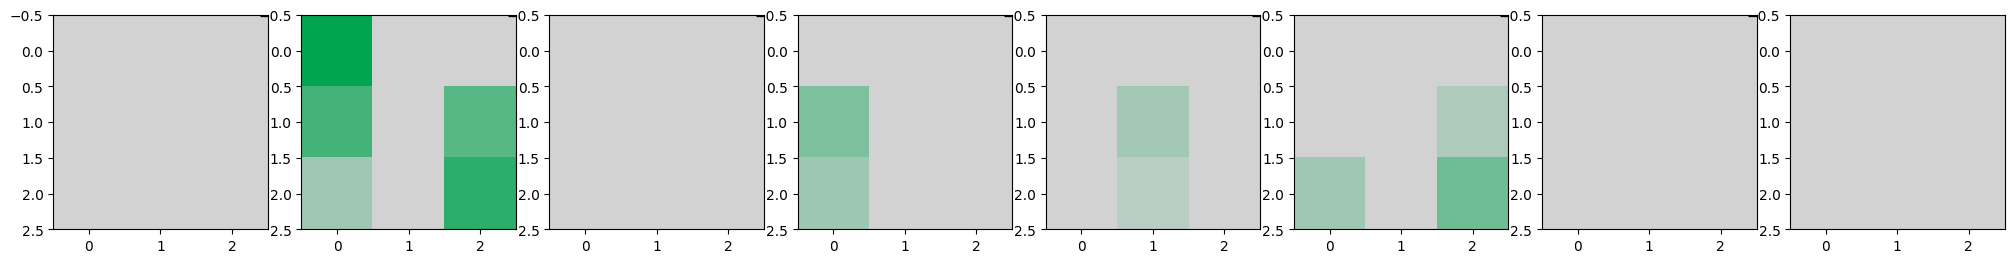

kernel


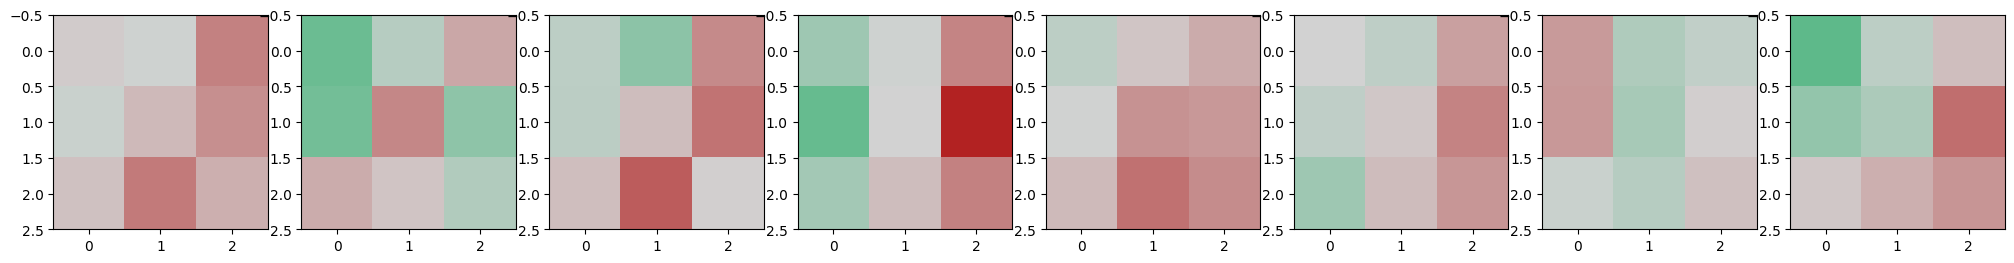

##### input activations ######
input activations


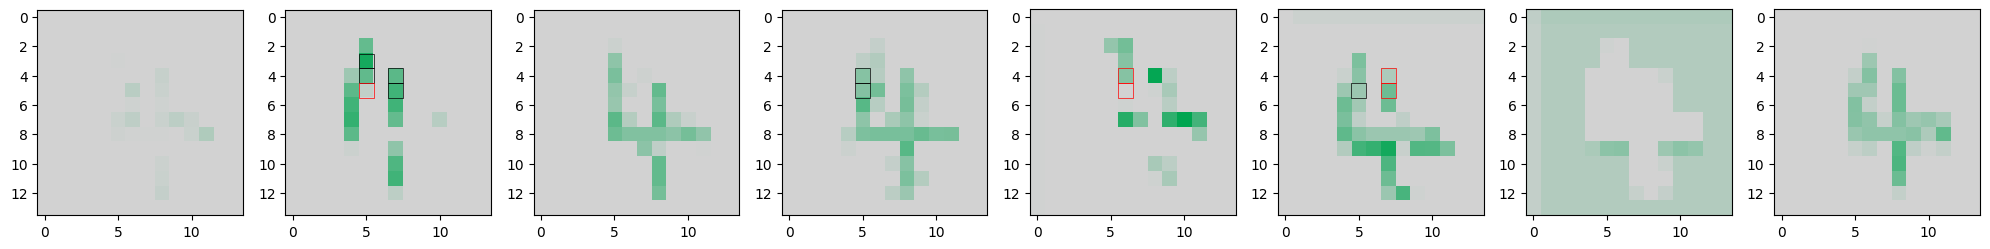

##### input activations ######
input activations


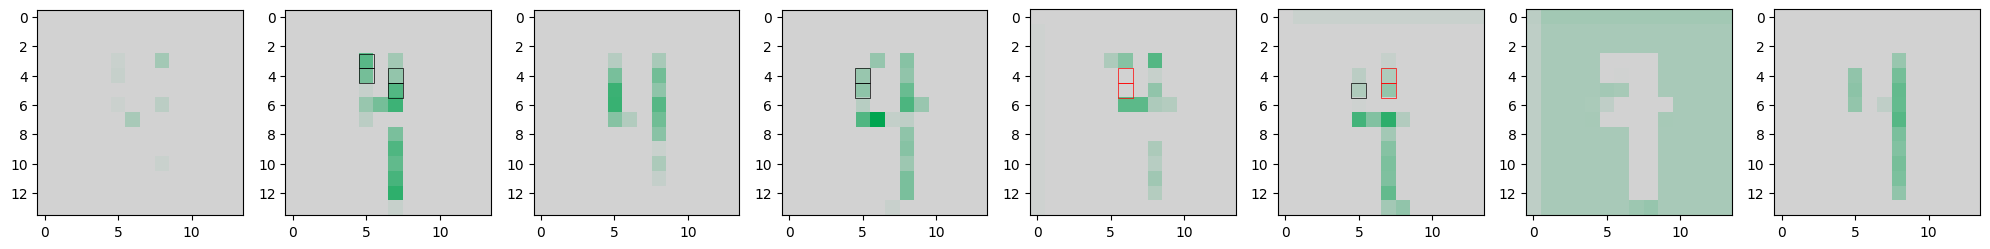

##### input activations ######
input activations


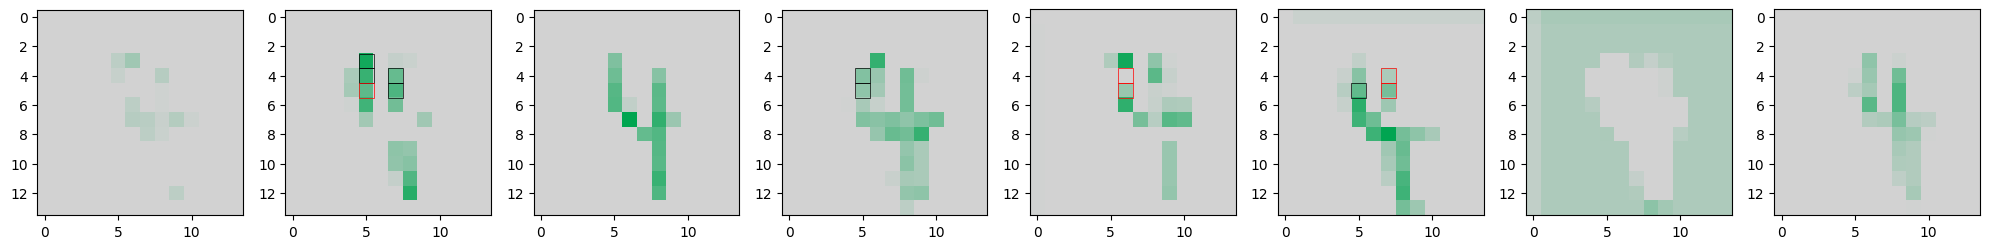

In [168]:
summarize_pattern_of_component(3, sm_ids, sparse_codes, dl, kernel)

In [ ]:
# def get_rect(y, x, ksize=3, stride=2, padding=1):
#     (y0,x0), (y1,x1) = get_receptive(y, x, ksize, stride, padding)
#     return (y0, x0, y1-y0, x1-x0)
axes = S(tsl(input_acts_0), (15,5), ncols=8, mode=MODE)
for ax in axes:
    mk_rect_on_ax(ax, *get_rect(R, C))
plt.show()
axes = S(tsl(input_acts_21), (15,5), ncols=8, mode=MODE)
for ax in axes:
    mk_rect_on_ax(ax, *get_rect(R, C))
plt.show()

In [64]:
find_pure_patches(sparse_codes, 7, 1e-5)

(array([53, 84]),)

In [52]:
sparse_codes[130]

array([1.11580135, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [48]:
sparse_codes.shape

(174, 30)

In [ ]:
#i. 